In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('/home/fverdian/class/soundspeed-scripts/kernels-fullnum/numerical-integrals')
from num_kernels import NumKernels, PLfromClass

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern"],
})

In [2]:
fx=0.1
t_ini = -6
fullt=np.linspace(t_ini,30, 200)
teval=0
kref=1.
supprshift=5
nk = NumKernels(fx=fx, kref=kref, fullt=fullt, rtol=0.0001)
def g_ank(k):
    return nk.g_an(-2*np.log(k/kref))

---
$F^{[2]}_\chi (q,k-q)$

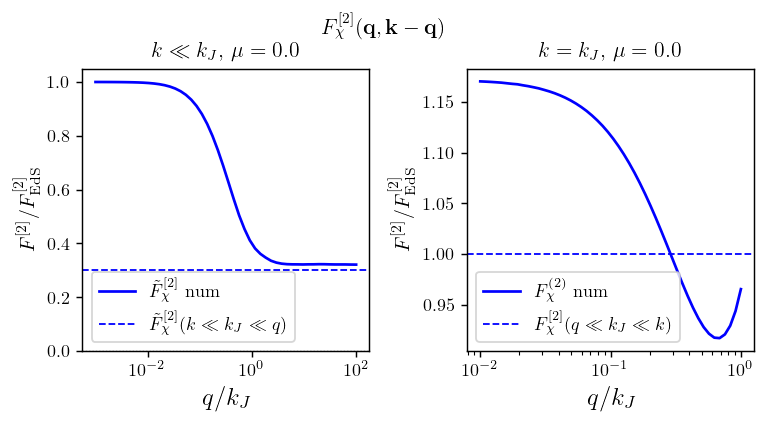

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 3.5), dpi=130)

mup=0. #MUST EVALUATE IT AT mu=0, otherwise the eds has a divergence
kplow=1.e-3
qlist=np.logspace(-3,2,50)
Flist_low=[];Flist_high=[]
for qp in qlist:
    print(f'q={qp:.1e}', end='\r')
    kMq = np.sqrt(kplow**2 + qp**2 - 2*kplow*qp*mup)
    cT12 = (kplow*mup-qp)/kMq
    F2c,_,F2x,_= nk.solve_F2([qp,kMq,cT12], return_timedep=False)
    Flist_low.append([F2x,nk.F2_0(kplow,qp,mup)])
Flist_low=np.array(Flist_low);

# First plot
ax1.plot(qlist,Flist_low[:,0]/Flist_low[:,1], 'b', label=r'$\tilde F_\chi^{[2]}$ num')
F2chi_qkMq_limB = 3/10
ax1.axhline(F2chi_qkMq_limB, color='b', linestyle='--', linewidth=1, label=r'$\tilde F_\chi^{[2]}(k\ll k_J \ll q$)')
ax1.axhline(0, color='k', linestyle=':', linewidth=0.7)
ax1.legend()
ax1.set_ylim([0.,None])
ax1.set_title(r'$k\ll k_J$'+r', $\mu='+'%.1f'%mup+r'$')
ax1.set_ylabel(r'$F^{[2]}/F^{[2]}_\mathrm{EdS}$', fontsize=11)
ax1.set_xscale('log')
ax1.set_xlabel(r'$q/k_J$', fontsize=14)

kphigh=1
qlist=np.logspace(-2,0,50)
Flist_high=[]
for qp in qlist:
    print(f'q={qp:.1e}', end='\r', flush=True)
    kMq = np.sqrt(kphigh**2 + qp**2 - 2*kphigh*qp*mup)
    cT12 = (kphigh*mup-qp)/kMq
    F2c,_,F2x,_=nk.solve_F2([qp,kMq,cT12], return_timedep=False)
    Flist_high.append([F2x/g_ank(kMq),nk.F2_0(kphigh,qp,mup)])
Flist_high=np.array(Flist_high)

# Second plot
ax2.plot(qlist,Flist_high[:,0]/Flist_high[:,1], 'b', label=r'$F_\chi^{(2)}$ num')
ax2.axhline(1, color='b', linestyle='--', linewidth=1, label=r'$F_\chi^{[2]}(q\ll k_J \ll k$)')
ax2.legend()
ax2.set_title(r'$k= k_J$'+r', $\mu='+'%.1f'%mup+r'$')
ax2.set_xscale('log')
# ax2.set_ylim([-0.5,0.5])
ax2.set_ylabel(r'$F^{[2]}/F^{[2]}_\mathrm{EdS}$', fontsize=11)
ax2.set_xlabel(r'$q/k_J$', fontsize=14)
plt.suptitle(r'$F_\chi^{[2]}(\mathbf{q},\mathbf{k}-\mathbf{q})$',y=0.92)
plt.tight_layout()
# plt.savefig('/home/fverdian/class/soundspeed-scripts/figure/F2chi_qkMq.pdf', bbox_inches='tight')
plt.show()

$F^{[2]}_c (q,k-q)$

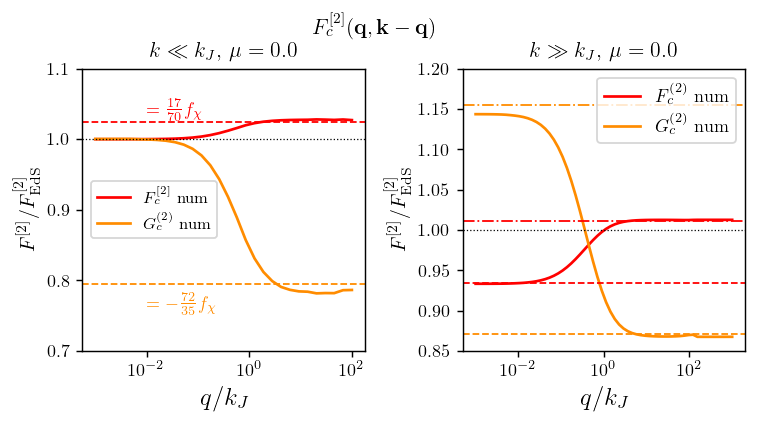

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 3.5), dpi=130)

mup=0. #MUST EVALUATE IT AT mu=0, otherwise the eds has a divergence
kplow=1.e-3
qlist=np.logspace(-3,2,30)
Flist_low=[];Flist_high=[]
for qp in qlist:
    print(f'q={qp:.1e}', end='\r')
    kMq = np.sqrt(kplow**2 + qp**2 - 2*kplow*qp*mup)
    cT12 = (kplow*mup-qp)/kMq
    F2c,G2_c,F2x,_=nk.solve_F2([qp,kMq,cT12])
    Flist_low.append([F2c,nk.F2_0(kplow,qp,mup), G2_c, nk.G2_0(kplow,qp,mup)])
Flist_low=np.array(Flist_low);

# First plot
ax1.plot(qlist,Flist_low[:,0]/Flist_low[:,1], 'r', label=r'$F_c^{[2]}$ num')
ax1.plot(qlist,Flist_low[:,2]/Flist_low[:,3], 'darkorange', label=r'$G_c^{(2)}$ num')
DeltaF2c_qkMq_limB = (51*fx)/210
ax1.axhline(1+DeltaF2c_qkMq_limB, color='r', linestyle='--', linewidth=1)
ax1.axhline(1, color='k', linestyle=':', linewidth=0.7)
ax1.axhline(1-72/35*fx, color='darkorange', linestyle='--', linewidth=1)

ax1.text(1.e-2, 1.035, r'$=\frac{17}{70}f_\chi$', color='r')
ax1.text(1.e-2, 0.76, r'$=-\frac{72}{35}f_\chi$', color='darkorange')
ax1.legend(fontsize=9, loc='center left')
ax1.set_ylim([0.7,1.1])
ax1.set_title(r'$k\ll k_J$'+r', $\mu='+'%.1f'%mup+r'$')
ax1.set_ylabel(r'$F^{[2]}/F^{[2]}_\mathrm{EdS}$', fontsize=11)
ax1.set_xscale('log')
ax1.set_xlabel(r'$q/k_J$', fontsize=14)

kphigh=10
qlist=np.logspace(-3,3,60)
Flist_high=[]
for qp in qlist:
    print(f'q={qp:.1e}', end='\r', flush=True)
    kMq = np.sqrt(kphigh**2 + qp**2 - 2*kphigh*qp*mup)
    cT12 = (kphigh*mup-qp)/kMq
    F2c,G2_c,F2x,_=nk.solve_F2([qp,kMq,cT12], return_timedep=False)
    Flist_high.append([F2c,nk.F2_0(kphigh,qp,mup), G2_c, nk.G2_0(kphigh,qp,mup)])
Flist_high=np.array(Flist_high)

# Second plot
ax2.plot(qlist,Flist_high[:,0]/Flist_high[:,1], 'r', label=r'$F_c^{(2)}$ num')
ax2.plot(qlist,Flist_high[:,2]/Flist_high[:,3], 'darkorange', label=r'$G_c^{(2)}$ num')

DeltaF2c_qkMq_limD = -23/35*fx
ax2.axhline(1+DeltaF2c_qkMq_limD, color='r', linestyle='--', linewidth=1)
DeltaF2c_qkMq_limC = 4/35*fx
ax2.axhline(1+DeltaF2c_qkMq_limC, color='r', linestyle='-.', linewidth=1)
ax2.axhline(1+54/35*fx, color='darkorange', linestyle='-.', linewidth=1)
ax2.axhline(1-9/7*fx, color='darkorange', linestyle='--', linewidth=1)

ax2.axhline(1, color='k', linestyle=':', linewidth=0.7)
ax2.legend()
ax2.set_title(r'$k\gg k_J$'+r', $\mu='+'%.1f'%mup+r'$')
ax2.set_xscale('log')
ax2.set_ylabel(r'$F^{[2]}/F^{[2]}_\mathrm{EdS}$', fontsize=11)
ax2.set_xlabel(r'$q/k_J$', fontsize=14)
ax2.set_ylim([0.85,1.2])

plt.suptitle(r'$F_c^{[2]}(\mathbf{q},\mathbf{k}-\mathbf{q})$',y=0.92)
plt.tight_layout()
# plt.savefig('/home/fverdian/class/soundspeed-scripts/figure/F2c_qkMq.pdf', bbox_inches='tight')
plt.show()

---
$F^{[3]}_\chi (k,q,-q)$

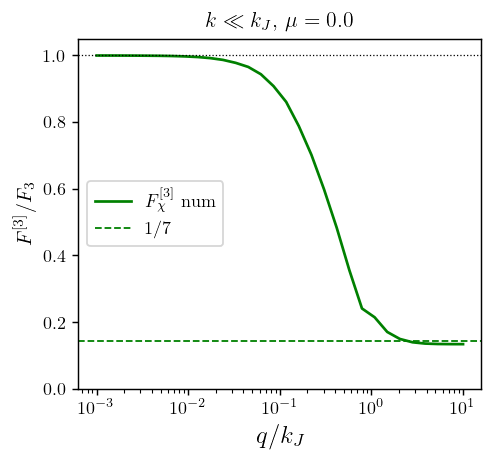

In [29]:
mup=0. #MUST EVALUATE IT AT mu=0, otherwise the eds has a divergence
kplow=1.e-4
qlist=np.logspace(-3,np.log10(10),30)
F3list_low=[]
for qp in qlist:
    print(f'q={qp:.1e}', end='\r', flush=True)
    F3c,_,F3x,_=nk.solve_F3([kplow,qp,mup], return_timedep=False)
    F3list_low.append([F3x/g_ank(kphigh),nk.F3_0(kplow,qp,mup)])
F3list_low=np.array(F3list_low).T;
plt.figure(figsize=(4, 3.5), dpi=130)

plt.plot(qlist,F3list_low[0]/F3list_low[1], 'g', label=r'$F_\chi^{[3]}$ num')
plt.axhline(1., color='k', linestyle=':', linewidth=0.7)
plt.axhline(1/7, color='g', linestyle='--', linewidth=1, label=r'1/7')
plt.ylim(0.,1.05)

plt.legend()
plt.title(r'$k\ll k_J$'+r', $\mu='+'%.1f'%mup+r'$')
plt.ylabel(r'$F^{[3]}/F_3$', fontsize=11)
plt.xscale('log')
plt.xlabel(r'$q/k_J$', fontsize=14)
# plt.savefig('/home/fverdian/class/soundspeed-scripts/figure/F3chi_limB.pdf', bbox_inches='tight')

plt.show()

$F^{[3]}_c (k,q,-q)$

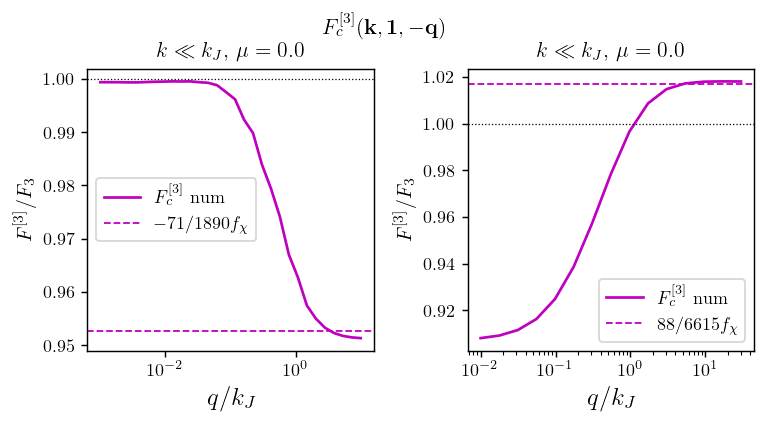

In [40]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 3.5), dpi=130)

mup=0. #MUST EVALUATE IT AT mu=0, otherwise the eds has a divergence
kplow=1.e-4
qlist=np.logspace(-3,np.log10(10),30)
F3list_low=[]
for qp in qlist:
    print(f'q={qp:.1e}', end='\r', flush=True)
    F3c,_,F3x,_=nk.solve_F3([kplow,qp,mup], return_timedep=False)
    F3list_low.append([F3c,nk.F3_0(kplow,qp,mup)])
F3list_low=np.array(F3list_low).T;

ax1.plot(qlist,F3list_low[0]/F3list_low[1], 'm', label=r'$F_c^{[3]}$ num')
ax1.axhline(1., color='k', linestyle=':', linewidth=0.7)
ax1.axhline((5/63 - 71/1890*fx)/(5/63), color='m', linestyle='--', linewidth=1, label=r'$- 71/1890 f_\chi$')

ax1.legend()
ax1.set_title(r'$k\ll k_J$'+r', $\mu='+'%.1f'%mup+r'$')
ax1.set_ylabel(r'$F^{[3]}/F_3$', fontsize=11)
ax1.set_xscale('log')
ax1.set_xlabel(r'$q/k_J$', fontsize=14)


# Second plot
kphigh=10
qlist=np.logspace(-2,np.log10(30),15)
F3list_high=[]
for qp in qlist:
    print(f'q={qp:.1e}', end='\r', flush=True)
    F3c,_,F3x,_=nk.solve_F3([kphigh,qp,mup], return_timedep=False)
    F3list_high.append([F3c,nk.F3_0(kphigh,qp,mup)])
F3list_high=np.array(F3list_high).T;

ax2.plot(qlist,F3list_high[0]/F3list_high[1], 'm', label=r'$F_c^{[3]}$ num')
ax2.axhline(1., color='k', linestyle=':', linewidth=0.7)
ax2.axhline((5/63 + 88/6615*fx)/(5/63), color='m', linestyle='--', linewidth=1, label=r'$ 88/6615 f_\chi$')

ax2.legend()
ax2.set_title(r'$k\ll k_J$'+r', $\mu='+'%.1f'%mup+r'$')
ax2.set_ylabel(r'$F^{[3]}/F_3$', fontsize=11)
ax2.set_xscale('log')
ax2.set_xlabel(r'$q/k_J$', fontsize=14)

plt.suptitle(r'$F_c^{[3]}(\mathbf{k},\mathbf{1},-\mathbf{q})$',y=0.92)
plt.tight_layout()
plt.show()